``Open in colab``

# Práctica 1: Estudio comparativo de algoritmos en un problema de k-armed bandit

**Descripción**: El experimento compara el rendimiento de algoritmos epsilon-greedy en un problema de k-armed bandit. Se generan gráficas de recompensas promedio para cada algoritmo.

**Asignatura**: Extensiones de Machine Learning, 2025/2026

**Autores**: 
* Alberto Ortega Pastor
* Manuel Salas Díaz
* Lola Conde Herrera

**Máster de Inteligencia Artificial**

**Facultad de Informática**

-----

## Preparación del entorno

Para la preparación del entorno, se clona el repositorio de GitHub con los archivos utilizados en el notebook.

!git clone https://github.com/Loicsav/SalasOrtegaConde1.git
%cd SalasOrtegaConde1

Una vez clonado el repositorio, se instalan las dependencias necesarias para la ejecución del notebook.

!pip install -r requirements.txt

Se importan las librerías necesarias.

In [1]:
import sys
import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedy
from arms import ArmNormal, Bandit, ArmBernoulli, ArmBinomial
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret, boxplot_estimaciones_brazos

A continuación, se utiliza una semilla para que el estudio sea reproducible. Además, se declaran las constantes del número de brazos, número de pasos, y número de ejecuciones para el estudio.

In [2]:
seed = 42
np.random.seed(seed)

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Algoritmo  ε-greedy

## Experimentos

Los algoritmos se ejecutan en el contexto de un problema del bandido de k-brazos, durante un número de pasos fijo. Se repite la ejecución un número fijo de veces.

En el estudio se utiliza un bandido de 10 brazos, ejecutado durante 1000 pasos, repetido un total de 500 ejecuciones. Se comparan los algoritmos con este procedimiento usando 3 bandidos con diferentes distribuciones de recompensas (distribución normal, distribución de bernouilli, y distribución binomial).

Para cada bandido, se comparan los algoritmos dada la recompensa promedio a lo largo del tiempo, el porcentaje de selección del brazo óptimo, y el porcentaje de selección y recompensas inferidas de cada brazo.

El siguiente código realiza un experimento con un bandido especificado, dada una lista de algoritmos, un número de pasos, y un número de ejecuciones. Devuelve una lista para cada algoritmo con la recompensa promedio de cada brazo y el número de veces que se ha seleccionado, valores que se obtienen de hacer la media de todas las ejecuciones. Además, se devuelve la recompensa obtenida en cada paso y el arrepentimiento, siendo estos los valores medios de todas las ejecuciones. Estos valores se utilizan para la realización de las gráficas usadas para la comparación de los algoritmos.

In [3]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    # Recopilar estadísticas de brazos para cada algoritmo
    arm_stats = []
    for algo in algorithms:
        arm_data = [
            {
                'arm': i + 1,  # Número del brazo (1 al k)
                'counts': 0.0,  # Número de veces seleccionado
                'values': 0.0,  # Recompensa promedio estimada
            }
            for i in range(algo.k)
        ]
        arm_stats.append(arm_data)

    # Recopilar todas las estimaciones finales de cada algoritmo en cada ejecución
    all_runs_data = []
    for algo in algorithms:
        all_runs_data.append([])

    # Recopilar el número de ejecuciones de cada brazo para cada algoritmo en cada ejecución
    all_runs_counts = []
    for algo in algorithms:
        all_runs_counts.append([])

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    regrets = np.zeros((len(algorithms), steps))  # Matriz para almacenar el regret acumulado.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                regrets[idx, step] += (current_bandit.get_expected_value(optimal_arm) - reward) # Acumular el regret obtenido en la matriz regrets para el algoritmo idx en el paso step.

                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1
        for arms_algo, algo in zip(arm_stats, algorithms):
            for arm_data in arms_algo:
                i = arm_data["arm"] -1
                arm_data["counts"] = arm_data["counts"] + algo.counts[i]
                arm_data["values"] = arm_data["values"] + float(algo.values[i])
        for arm_values, algo in zip(all_runs_data, algorithms):
            lista = []
            for i in range(k):
                lista.append(algo.values[i])
            arm_values.append(lista)

        for arm_counts, algo in zip(all_runs_counts, algorithms):
            lista = []
            for i in range(k):
                lista.append(algo.counts[i])
            arm_counts.append(lista)


    rewards /= runs
    regrets /= runs
    optimal_selections /= runs
    
    # Recopilar estadísticas de brazos para cada algoritmo
    for arms_algo, algo in zip(arm_stats, algorithms):
            for arm_data in arms_algo:
                i = arm_data["arm"] -1
                arm_data["values"] = arm_data["values"]/runs
                arm_data["counts"] = int(arm_data["counts"]/runs)

    return rewards, optimal_selections, arm_stats, regrets, all_runs_data, all_runs_counts

## ``Experimento distribución Normal``

A continuación, se realiza el experimento con un bandido cuyas recompensas de cada brazo siguen una distribución normal con desviación estándar 1. Se comparan los algoritmos ε greedy con ε=0, ε=0.1, y ε=0.01.

In [4]:
# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets, all_runs_data, all_runs_counts = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


### Visualización

En primer lugar, se presenta un boxplot que muestra las estimaciones finales del valor esperado de cada brazo para cada algoritmo. La media real de la distribución normal de cada brazo se muestra con una línea verde.

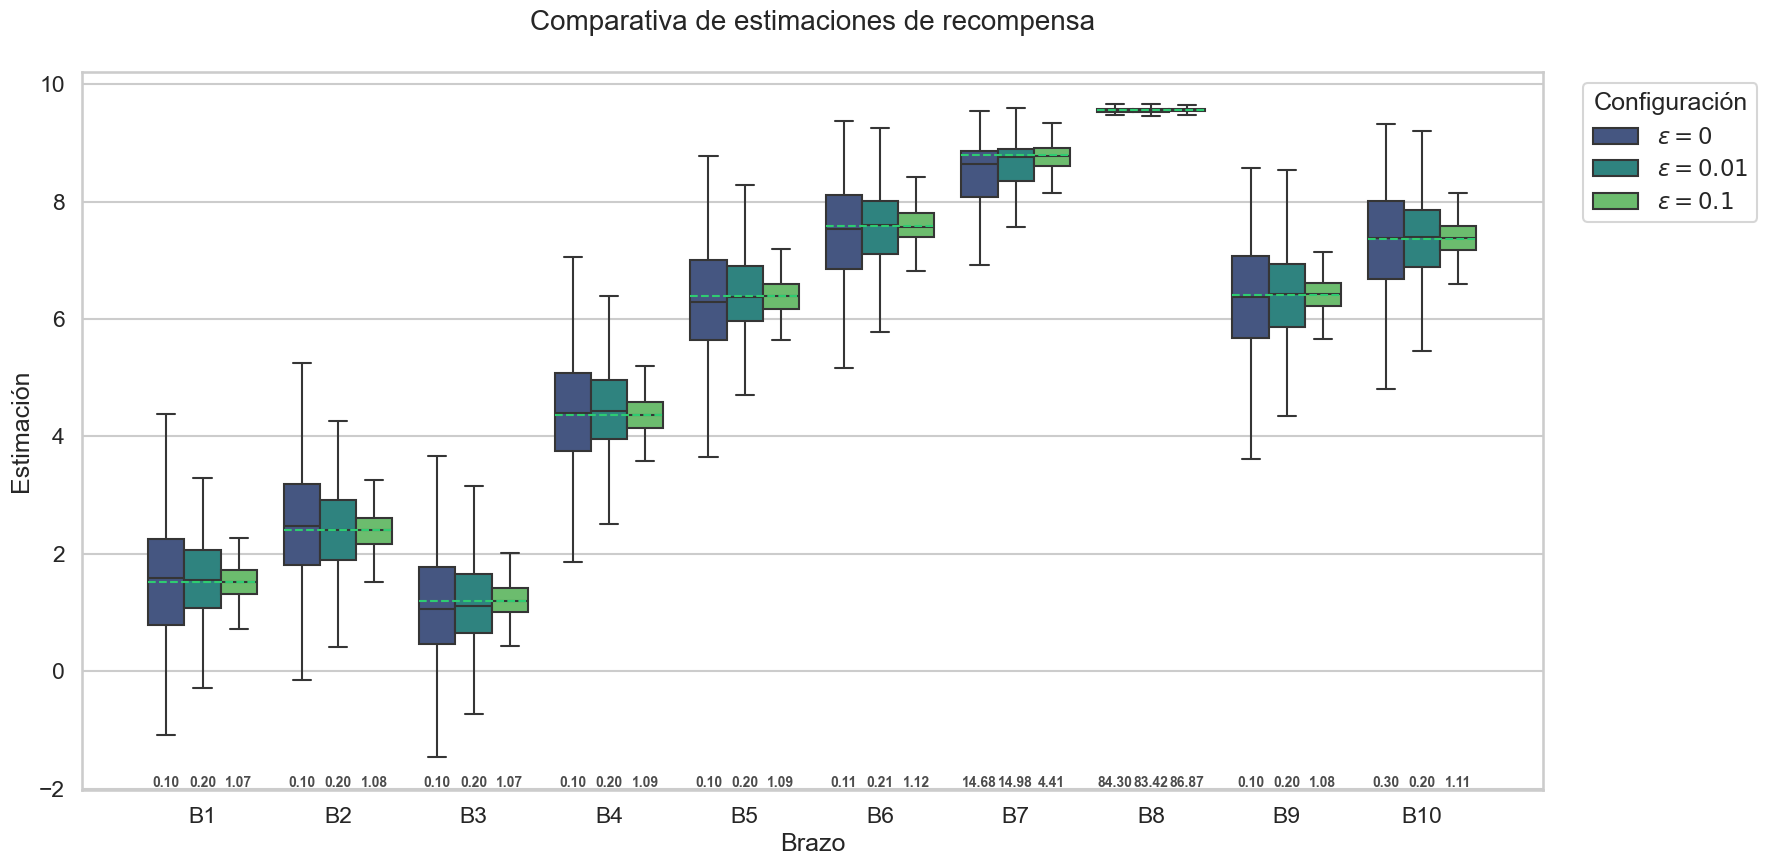

In [5]:
boxplot_estimaciones_brazos(all_runs_data, all_runs_counts, algorithms, [bandit.get_expected_value(i) for i in range(k)])

Los brazos seleccionados con menor frecuencian tienen estimaciones más variables, distribuidas al rededor de la media de la distribución de dicho brazo.

El algoritmo ε-greedy con ε=0.1 tiene una distribución menos ancha porque cada brazo se ha seleccionado un mínimo de un 1.1%. Esto corresponde con el porcentaje de exploración del algoritmo, dado que si se explora un 10% de los pasos, y hay un total de 10 brazos, cada brazo se debería seleccionar un 1% de las ocasiones en media. El 0.1% restante corresponde con el inicio del algoritmo, en el que se selecciona cada brazo una vez antes de comenzar.

El algoritmo ε-greedy con ε=0.01 tiene una distribución un poco más ancha porque cada brazo se ha seleccionado un  menor número de veces, correspondiente a un 0.2%. Esto corresponde con el porcentaje de exploración, dado que si el algoritmo explora un 1% de los pasos, y hay un total de 10 brazos, cada brazo se debería seleccionar un 0.1% de las ocasiones. El 0.1% restante corresponde con el inicio del algoritmo.

Por último, el algoritmo ε-greedy con ε=0 tiene las distribuciones más anchas debido a que se ejecuta un menor número de veces cada brazo, siendo su mayoría 0.1% por la inicialización del algoritmo.

Esto muestra la relevancia de ε para la estimación de las recompensas. Además, se espera que los intervalos de ε=0.01 y ε=0.1 sigan haciéndose más estrechos con el tiempo por su componente exploratoria.

Por otra parte, en todos los algoritmos el brazo número 8, se selecciona al menos un 83% de las veces en media. Esto se ve reflejado en su distribución, siendo esta muy concentrada en el valor real medio de la distribución del brazo. Este brazo corresponde con el brazo óptimo.

El brazo número 7 se ha seleccionado un 14% de las ocasiones en los algoritmos con ε=0.01 y ε=0, siendo este el segundo con media de distribución mayor. El algoritmo con ε=0.1 selecciona el brazo 7 un menor número de veces, pero lo selecciona con mayor frecuencia que al resto, un 4%. Esto ocurre por ser el brazo con media más cercana al brazo óptimo, al algoritmo le cuesta darse cuenta que el óptimo es el número 8.

TODO: Explicar por qué la diferencia (14 vs 4)

A continación, se muestra la recompensa promedio que obtiene cada algoritmo a lo largo del tiempo.

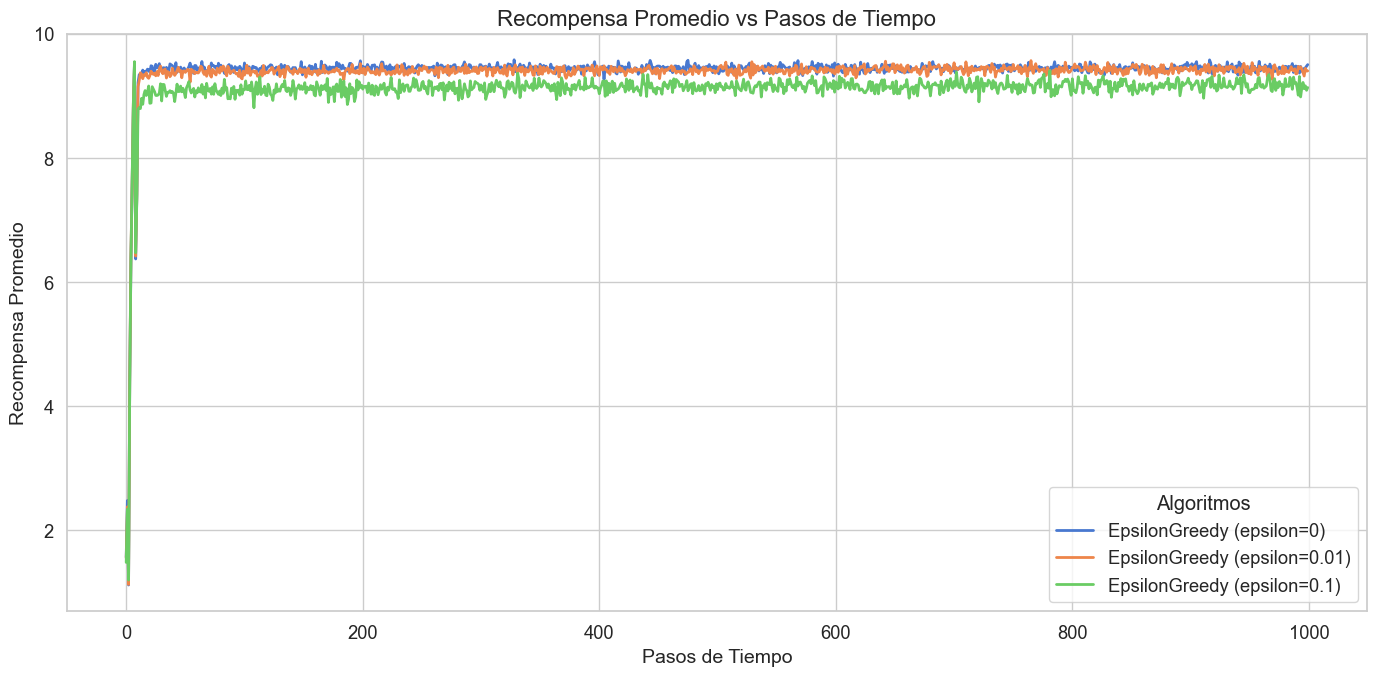

In [6]:
plot_average_rewards(steps, rewards, algorithms)

Al inicio el algoritmo tiene una pendiente muy pronunciada por la fase de inicialización del algoritmo, en la que se selecciona cada brazo una vez. Se observa que los algoritmos rápidamente convergen a una recompensa media estable, en un valor cercano al 9.5, lo que corresponde con la media de distribución de recompensas del brazo óptimo, un 9.56.

A su vez, vemos como el algoritmo con ε=0.1 consigue un promedio de recompensas menor. Esto podría deberse a que este algoritmo tiene una mayor tasa de exploración, por lo que, en el punto en el que los algoritmos con ε=0.1 y ε=0.01 convergen y seleccionan el brazo óptimo, el algoritmo con ε=0.1 escoge brazos subóptimos un 10% de las ocasiones, frente al 1% del algoritmo con ε=0.01.

A continuación, se muestra el porcentaje de selección del brazo óptimo a lo largo del tiempo

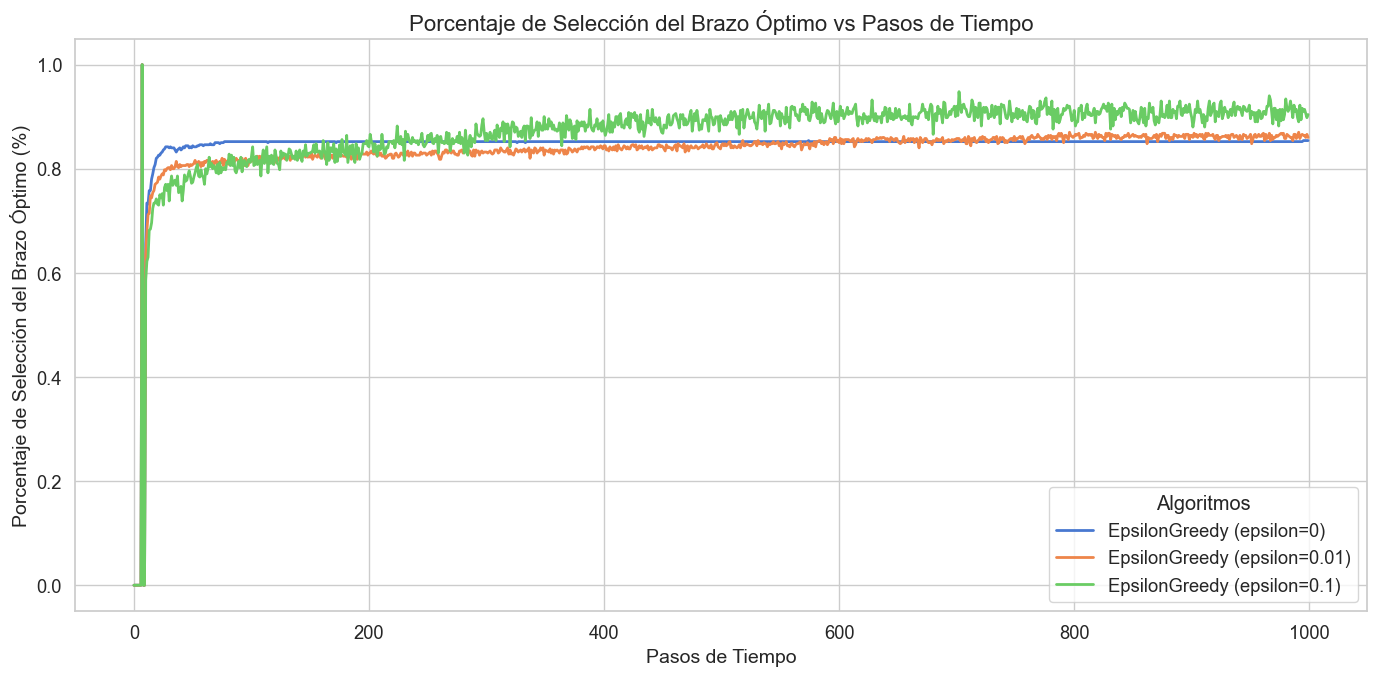

In [7]:
plot_optimal_selections(steps, optimal_selections, algorithms)

Para ε=0, el porcentaje se estabiliza pronto, manteniéndose estable a partir de 100 pasos. Esto se debe a que, si el algoritmo selecciona un brazo subóptimo, no descubrirá el brazo óptimo por la falta de exploración.

Para ε=0.01, el porcentaje de ocasiones en los que se escoge el brazo óptimo sube con el tiempo a un ritmo constante.

Para ε=0.1, el porcentaje de ocasiones en los que se escoge el brazo óptimo aumenta más rápido que con ε=0.01, dada su mayor tasa de exploración, que permite identificar antes el brazo óptimo. La curva se estabiliza alrededor del 90%, debido a que el algoritmo explora un 10% de las ocasiones.

Se espera que, si se ejecuta un mayor número de pasos, el algoritmo con ε=0.01 termine superando al algoritmo con ε=0.1, dado que explora un 1% de las ocasiones, por lo que al identificar el brazo óptimo, lo explota con mayor frecuencia.

A continuación, se muestra el regret acumulado durante los pasos del tiempo. 

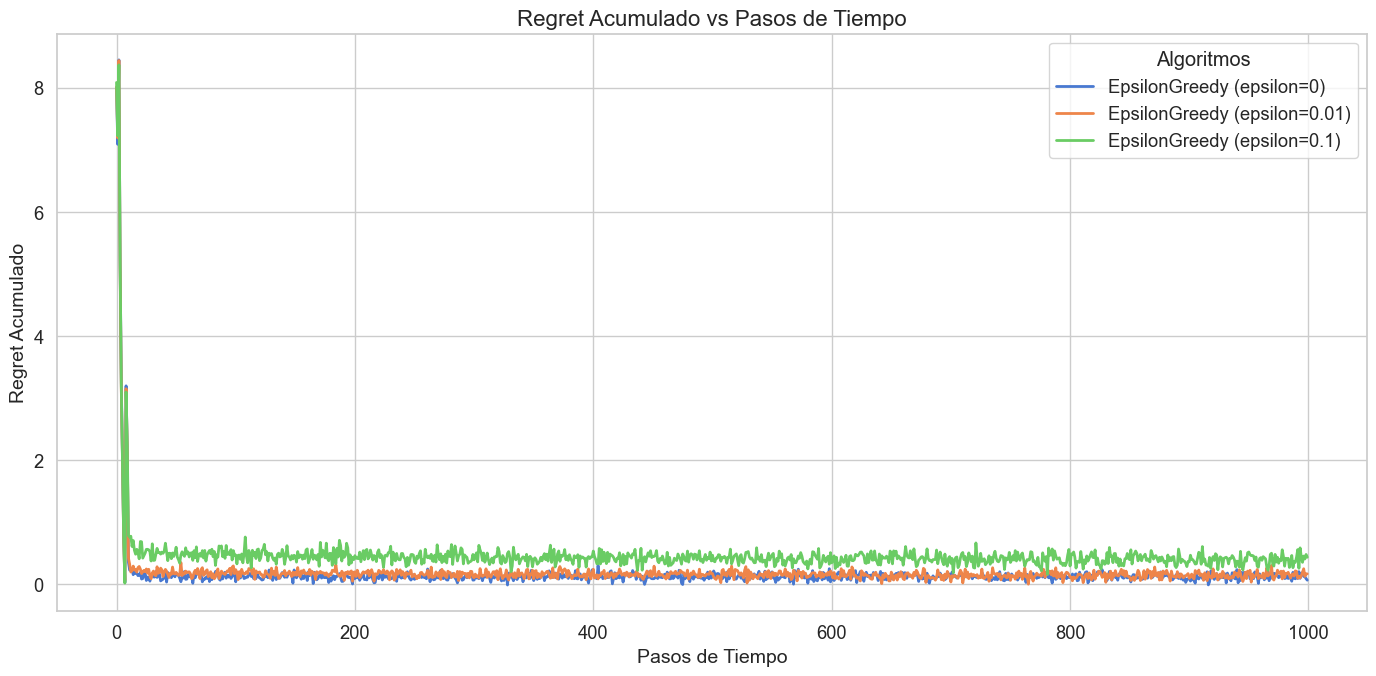

In [8]:
plot_regret(steps, regrets, algorithms)

Dado que el algoritmo con ε=0.01 tiene una recompensa media mayor, obtiene un menor regret.

Aunque el algoritmo con ε=0.1 descubre antes el brazo óptimo por su tasa de exploración, selecciona brazos subóptimos con más frecuencia, lo que incrementa su regret.

El algoritmo con ε=0.01 tarda más tiempo en identificar el brazo óptimo, y un 14% de las ocasiones selecciona el brazo 7, que es el segundo con media mayor de recompensa, frente al 4% del algoritmo con ε=0.1. Sin embargo, el regret añadido por esas decisiones es menor que el añadido por el 10% de exploración del algoritmo con ε=0.1, donde selecciona brazos con recompensas medias mucho menores.

## ``Experimento distribución Bernoulli``

In [ ]:
# Creación del bandit
bandit = Bandit(arms=ArmBernoulli.generate_arms(k)) # Generar un bandido con k brazos de distribución de Bernoulli
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets, all_runs_data, all_runs_counts  = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBernoulli(p=0.7), ArmBernoulli(p=0.35), ArmBernoulli(p=0.79), ArmBernoulli(p=0.34), ArmBernoulli(p=0.42), ArmBernoulli(p=0.08), ArmBernoulli(p=0.68), ArmBernoulli(p=0.69), ArmBernoulli(p=0.65), ArmBernoulli(p=0.73)
Optimal arm: 3 with expected reward=0.79


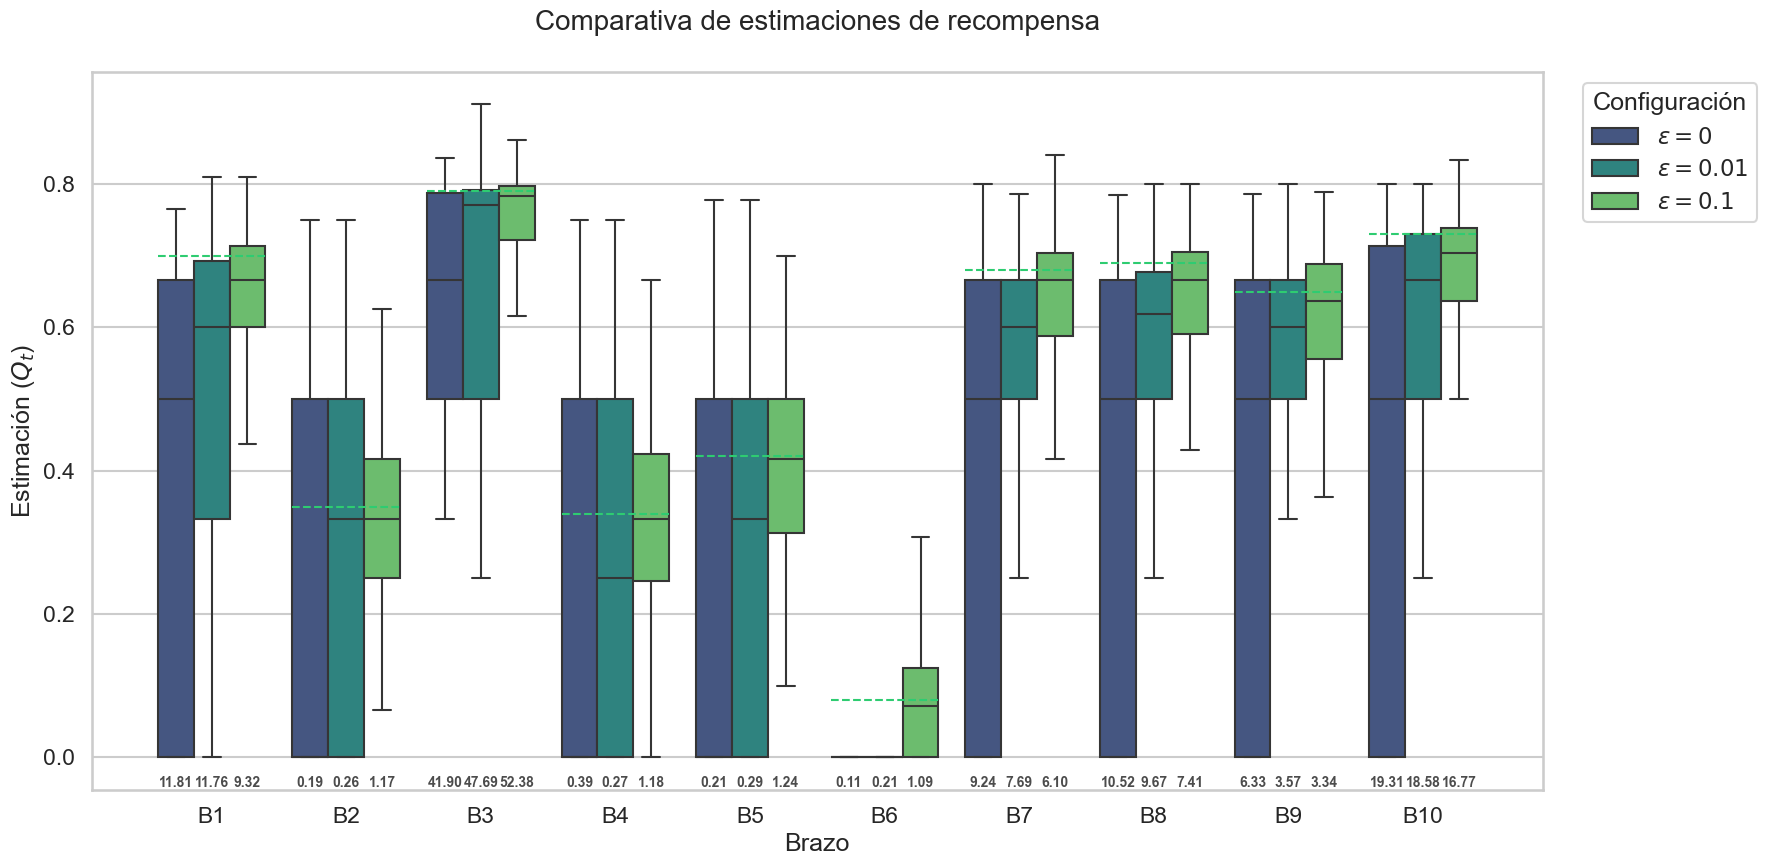

In [ ]:
boxplot_estimaciones_brazos(all_runs_data, all_runs_counts, algorithms, [bandit.get_expected_value(i) for i in range(k)])

### Visualización

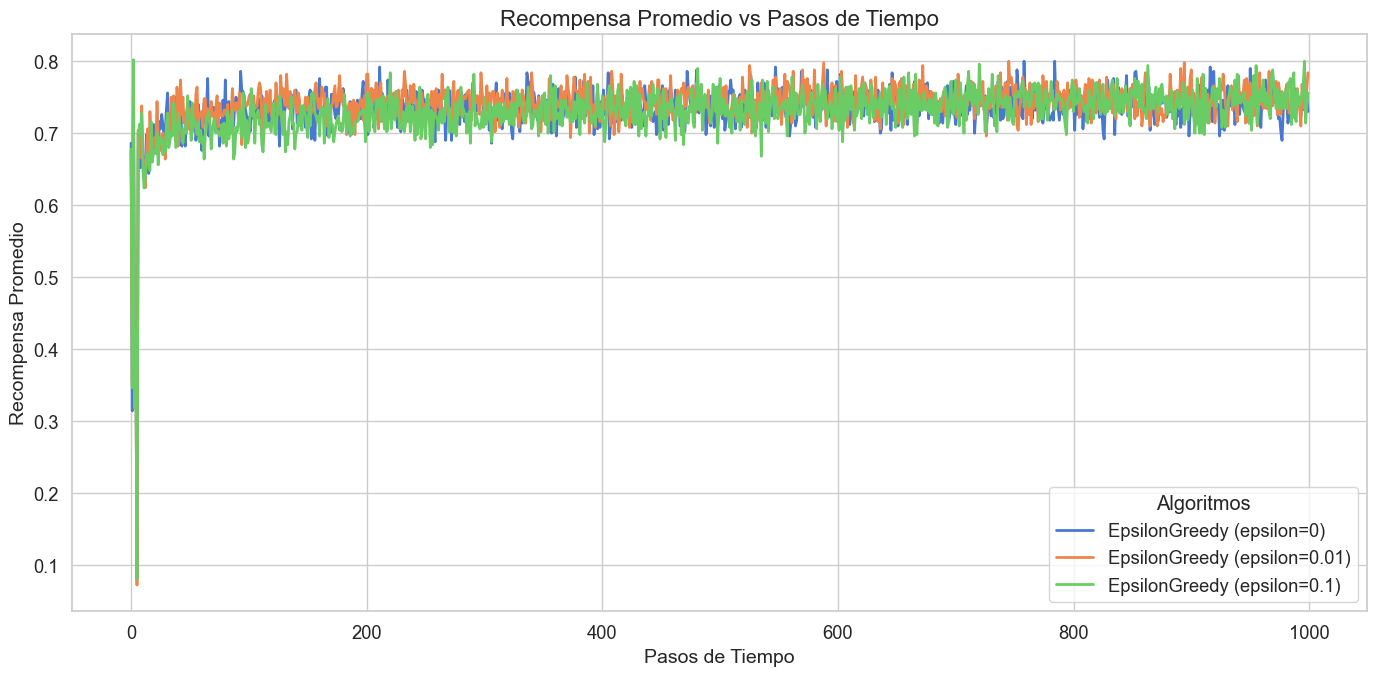

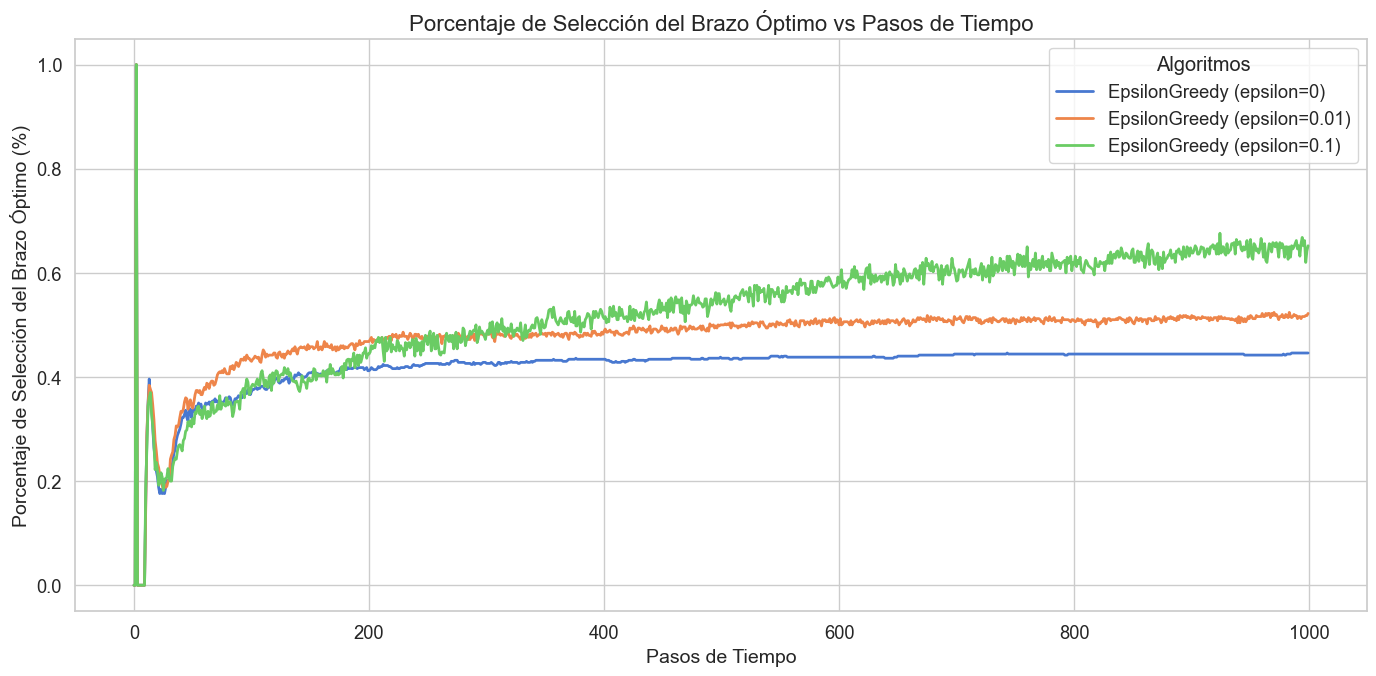


Estadísticas de brazos - EpsilonGreedy (epsilon=0)
Brazo 1: Recompensa Promedio = 0.4257, Selecciones = 118
Brazo 2: Recompensa Promedio = 0.1694, Selecciones = 1
Brazo 3: Recompensa Promedio = 0.5467, Selecciones = 418 (ÓPTIMO)
Brazo 4: Recompensa Promedio = 0.1981, Selecciones = 3
Brazo 5: Recompensa Promedio = 0.2321, Selecciones = 2
Brazo 6: Recompensa Promedio = 0.0413, Selecciones = 1
Brazo 7: Recompensa Promedio = 0.4313, Selecciones = 92
Brazo 8: Recompensa Promedio = 0.4255, Selecciones = 105
Brazo 9: Recompensa Promedio = 0.3936, Selecciones = 63
Brazo 10: Recompensa Promedio = 0.4501, Selecciones = 193


c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:318: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


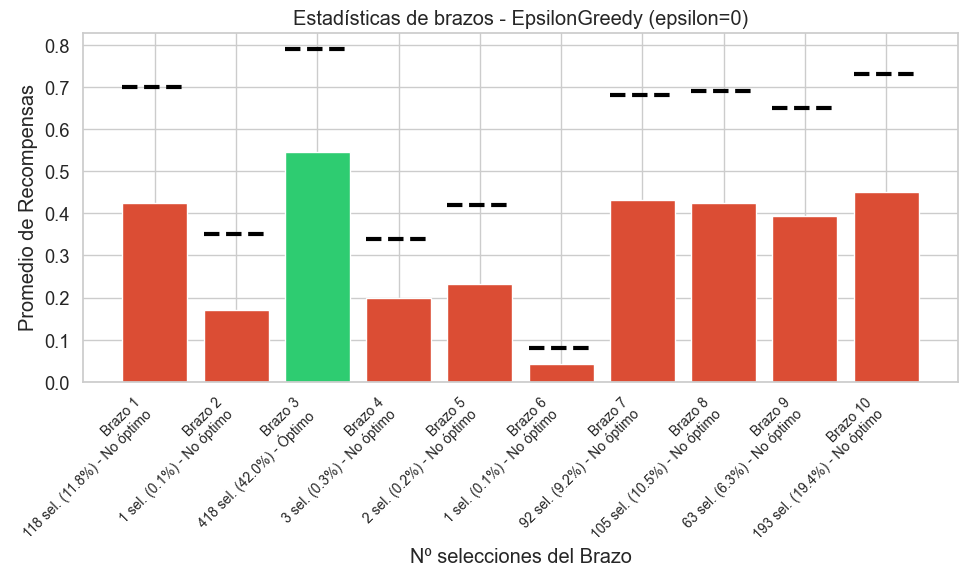


Estadísticas de brazos - EpsilonGreedy (epsilon=0.01)
Brazo 1: Recompensa Promedio = 0.4985, Selecciones = 117
Brazo 2: Recompensa Promedio = 0.2546, Selecciones = 2
Brazo 3: Recompensa Promedio = 0.6388, Selecciones = 476 (ÓPTIMO)
Brazo 4: Recompensa Promedio = 0.2403, Selecciones = 2
Brazo 5: Recompensa Promedio = 0.2767, Selecciones = 2
Brazo 6: Recompensa Promedio = 0.0572, Selecciones = 2
Brazo 7: Recompensa Promedio = 0.5070, Selecciones = 76
Brazo 8: Recompensa Promedio = 0.5119, Selecciones = 96
Brazo 9: Recompensa Promedio = 0.4951, Selecciones = 35
Brazo 10: Recompensa Promedio = 0.5535, Selecciones = 185


c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:318: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


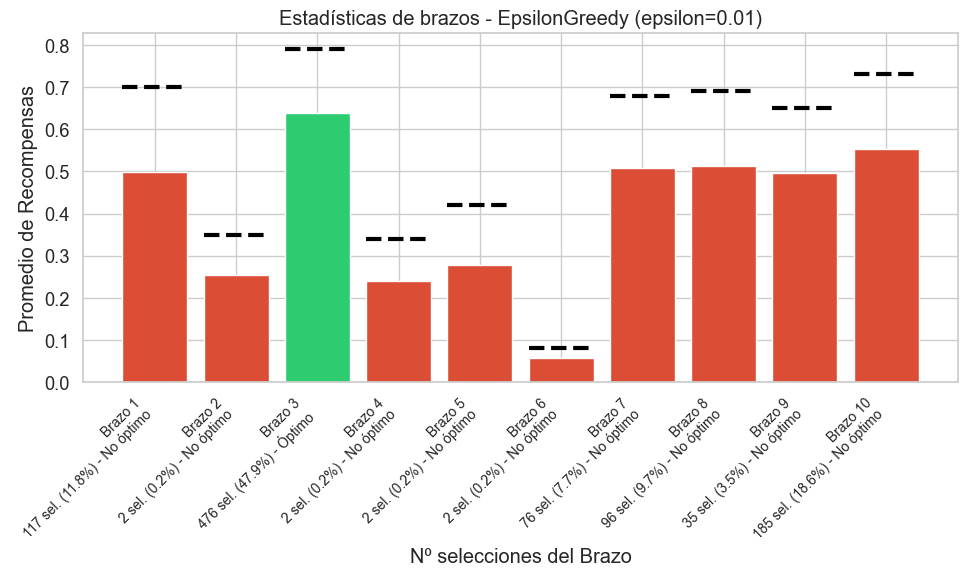

c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:318: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)



Estadísticas de brazos - EpsilonGreedy (epsilon=0.1)
Brazo 1: Recompensa Promedio = 0.6446, Selecciones = 93
Brazo 2: Recompensa Promedio = 0.3278, Selecciones = 11
Brazo 3: Recompensa Promedio = 0.7500, Selecciones = 523 (ÓPTIMO)
Brazo 4: Recompensa Promedio = 0.3335, Selecciones = 11
Brazo 5: Recompensa Promedio = 0.4109, Selecciones = 12
Brazo 6: Recompensa Promedio = 0.0744, Selecciones = 10
Brazo 7: Recompensa Promedio = 0.6370, Selecciones = 61
Brazo 8: Recompensa Promedio = 0.6415, Selecciones = 74
Brazo 9: Recompensa Promedio = 0.6168, Selecciones = 33
Brazo 10: Recompensa Promedio = 0.6746, Selecciones = 167


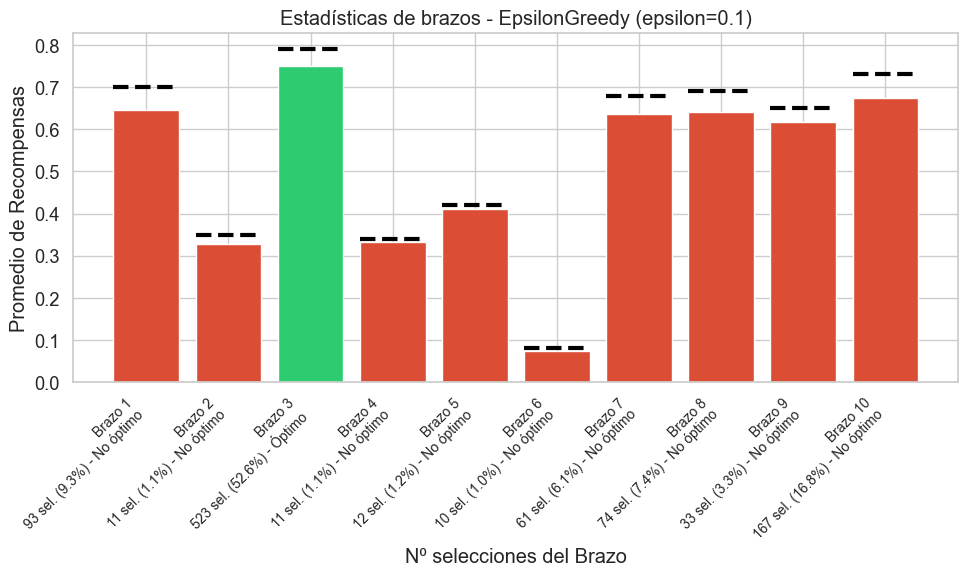

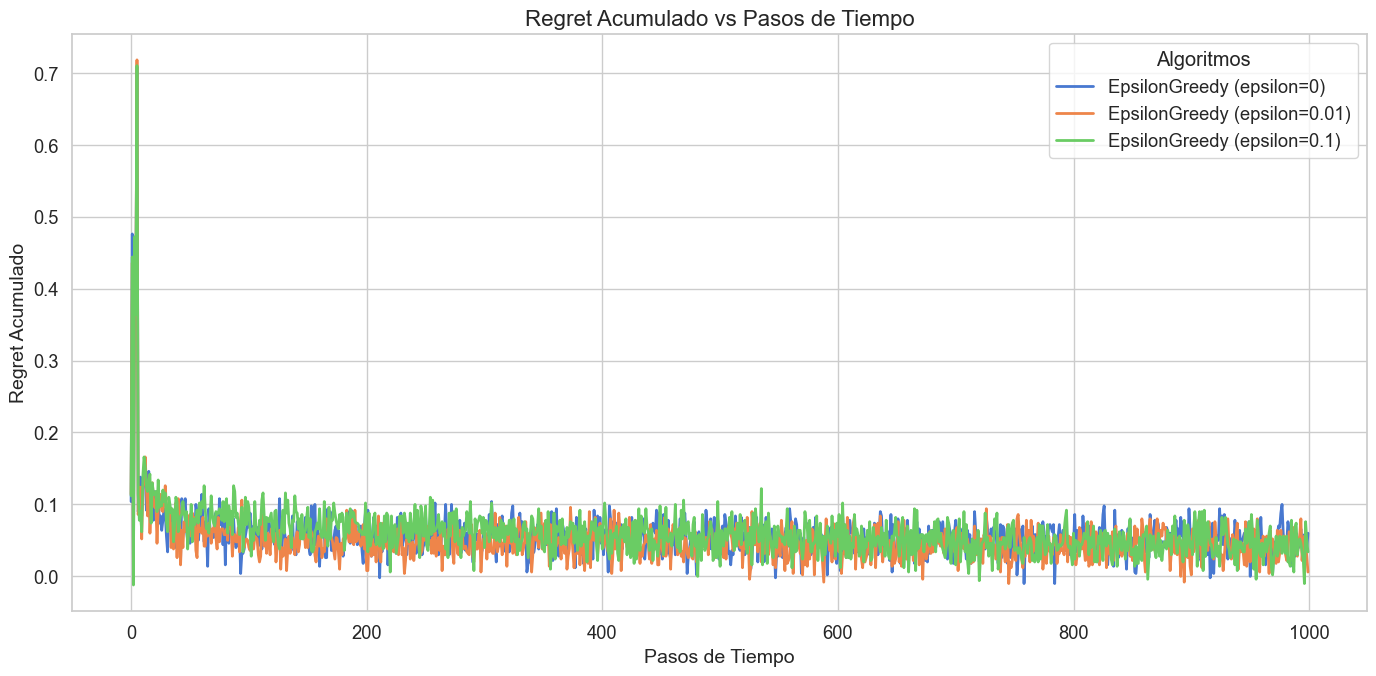

In [ ]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arm_stats, algorithms, [bandit.get_expected_value(i) for i in range(k)])
plot_regret(steps, regrets, algorithms)

### Análisis

## ``Experimento distribución Binomial``

In [ ]:
# Creación del bandit
bandit = Bandit(arms=ArmBinomial.generate_arms(k)) # Generar un bandido con k brazos de distribución binomial
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets, all_runs_data, all_runs_counts = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBinomial(n=10, p=0.38), ArmBinomial(n=10, p=0.7), ArmBinomial(n=10, p=0.43), ArmBinomial(n=10, p=0.87), ArmBinomial(n=10, p=0.41), ArmBinomial(n=10, p=0.54), ArmBinomial(n=10, p=0.31), ArmBinomial(n=10, p=0.19), ArmBinomial(n=10, p=0.35), ArmBinomial(n=10, p=0.95)
Optimal arm: 10 with expected reward=9.5


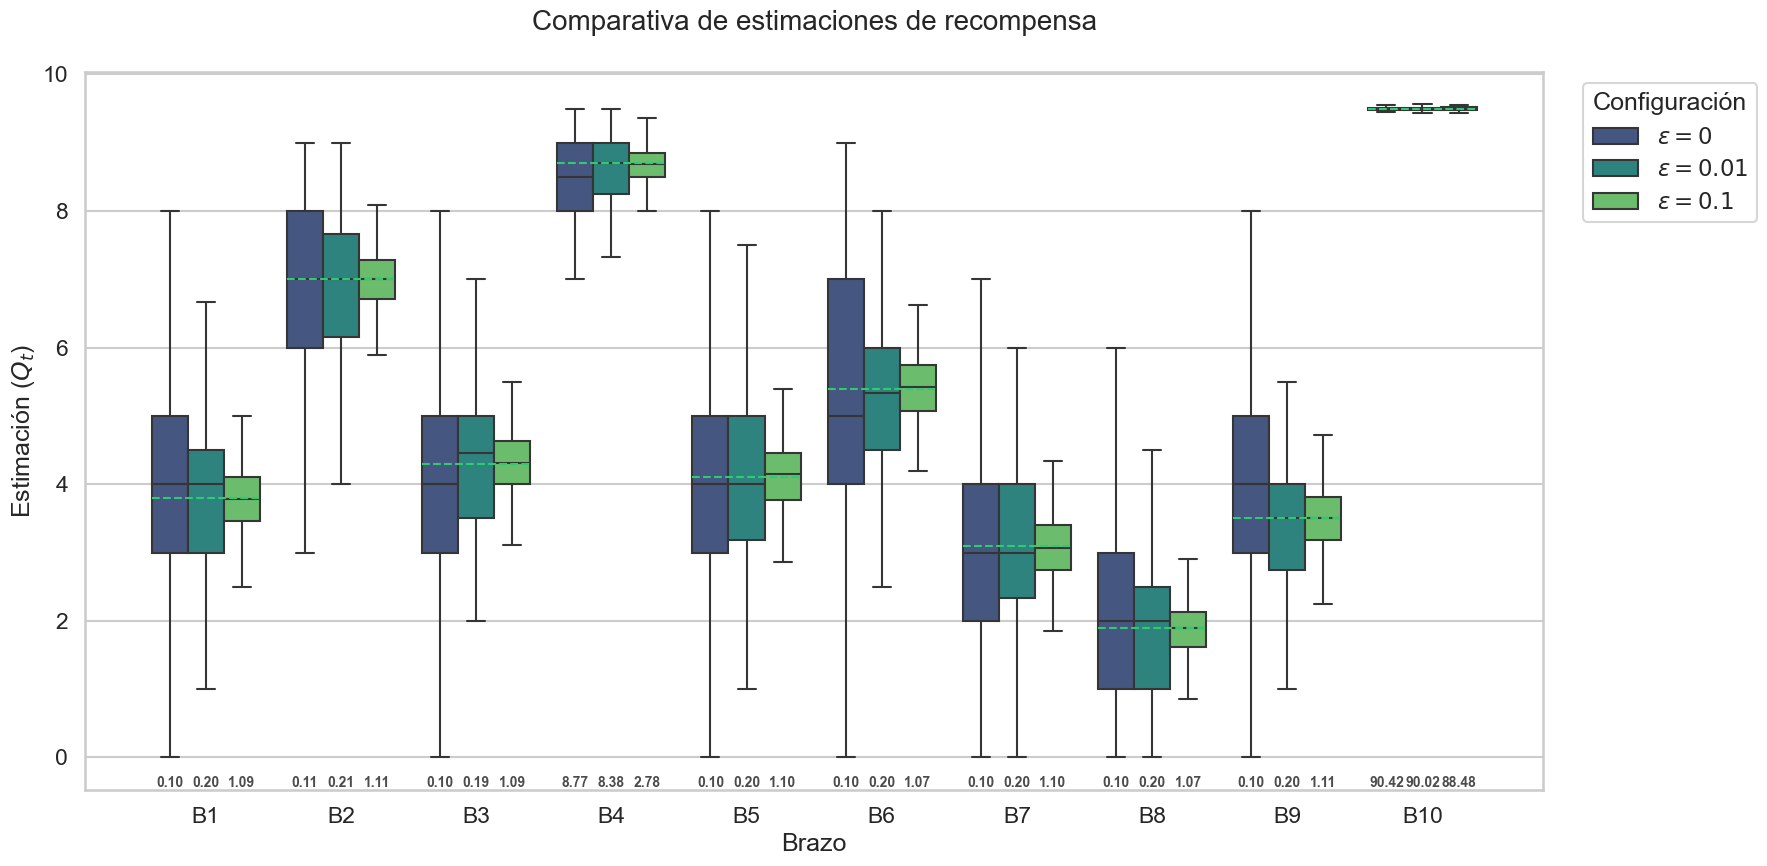

In [ ]:
boxplot_estimaciones_brazos(all_runs_data, all_runs_counts, algorithms, [bandit.get_expected_value(i) for i in range(k)])

### Visualización

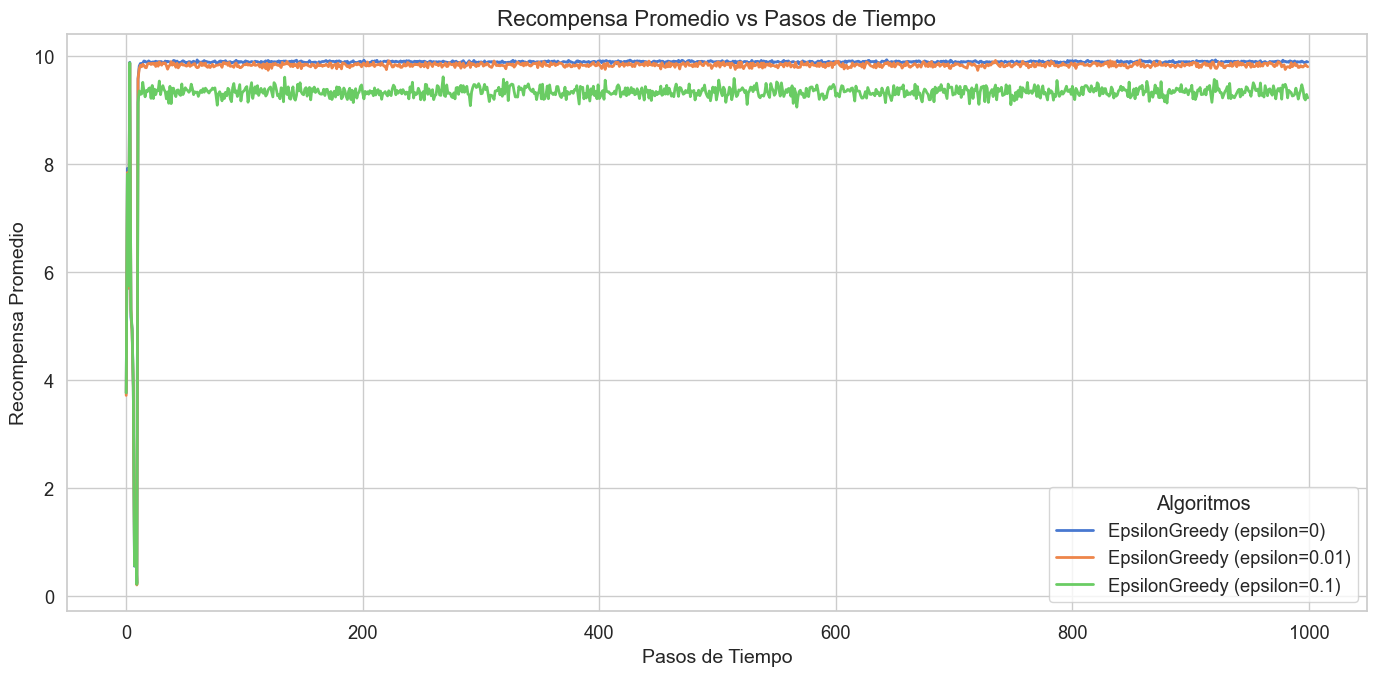

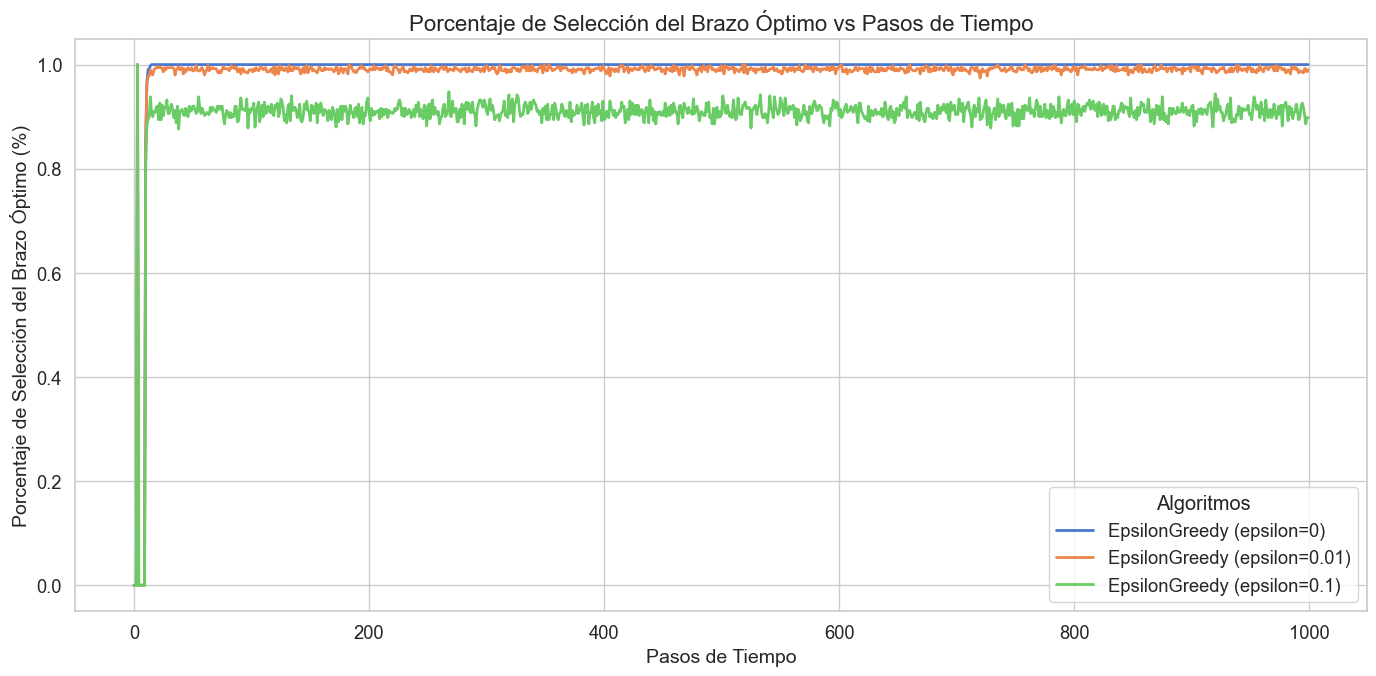


Estadísticas de brazos - EpsilonGreedy (epsilon=0)
Brazo 1: Recompensa Promedio = 3.7600, Selecciones = 1
Brazo 2: Recompensa Promedio = 7.7633, Selecciones = 1
Brazo 3: Recompensa Promedio = 5.6977, Selecciones = 1
Brazo 4: Recompensa Promedio = 9.8997, Selecciones = 990 (ÓPTIMO)
Brazo 5: Recompensa Promedio = 5.1650, Selecciones = 1
Brazo 6: Recompensa Promedio = 4.9480, Selecciones = 1
Brazo 7: Recompensa Promedio = 3.8680, Selecciones = 1
Brazo 8: Recompensa Promedio = 0.5520, Selecciones = 1
Brazo 9: Recompensa Promedio = 1.1180, Selecciones = 1
Brazo 10: Recompensa Promedio = 0.2380, Selecciones = 1


c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:318: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


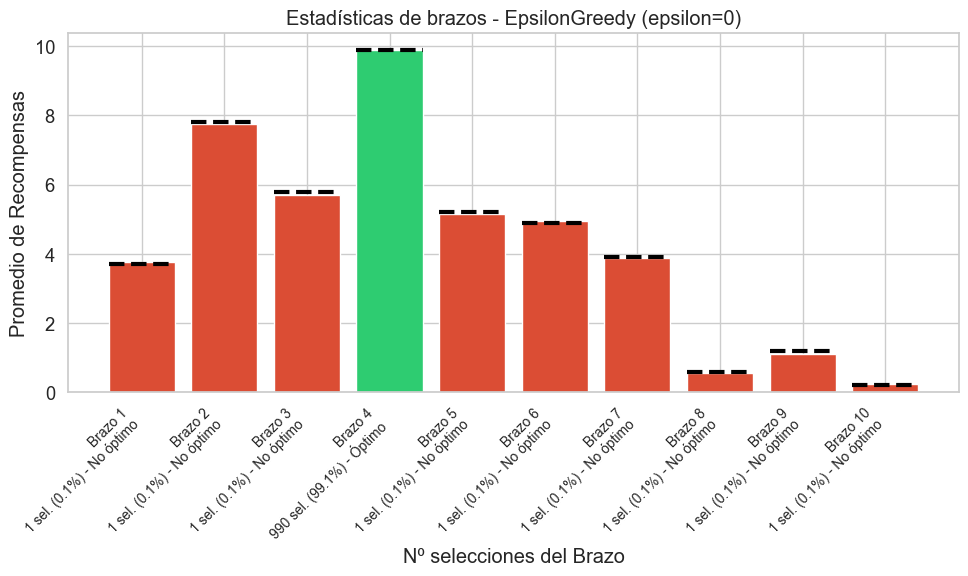


Estadísticas de brazos - EpsilonGreedy (epsilon=0.01)
Brazo 1: Recompensa Promedio = 3.7543, Selecciones = 2
Brazo 2: Recompensa Promedio = 7.8011, Selecciones = 2
Brazo 3: Recompensa Promedio = 5.6777, Selecciones = 1
Brazo 4: Recompensa Promedio = 9.8993, Selecciones = 981 (ÓPTIMO)
Brazo 5: Recompensa Promedio = 5.2808, Selecciones = 1
Brazo 6: Recompensa Promedio = 4.9103, Selecciones = 1
Brazo 7: Recompensa Promedio = 3.8908, Selecciones = 2
Brazo 8: Recompensa Promedio = 0.6412, Selecciones = 2
Brazo 9: Recompensa Promedio = 1.1531, Selecciones = 1
Brazo 10: Recompensa Promedio = 0.2094, Selecciones = 2


c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:318: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


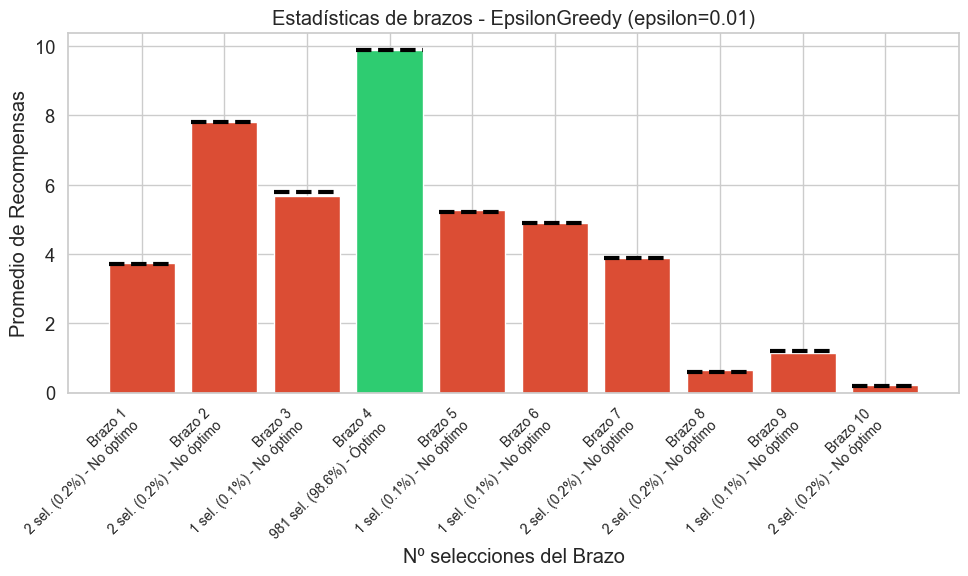

c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:318: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)



Estadísticas de brazos - EpsilonGreedy (epsilon=0.1)
Brazo 1: Recompensa Promedio = 3.7170, Selecciones = 10
Brazo 2: Recompensa Promedio = 7.8139, Selecciones = 11
Brazo 3: Recompensa Promedio = 5.7436, Selecciones = 10
Brazo 4: Recompensa Promedio = 9.9002, Selecciones = 902 (ÓPTIMO)
Brazo 5: Recompensa Promedio = 5.1900, Selecciones = 10
Brazo 6: Recompensa Promedio = 4.8884, Selecciones = 10
Brazo 7: Recompensa Promedio = 3.8928, Selecciones = 10
Brazo 8: Recompensa Promedio = 0.6039, Selecciones = 10
Brazo 9: Recompensa Promedio = 1.1838, Selecciones = 11
Brazo 10: Recompensa Promedio = 0.2015, Selecciones = 10


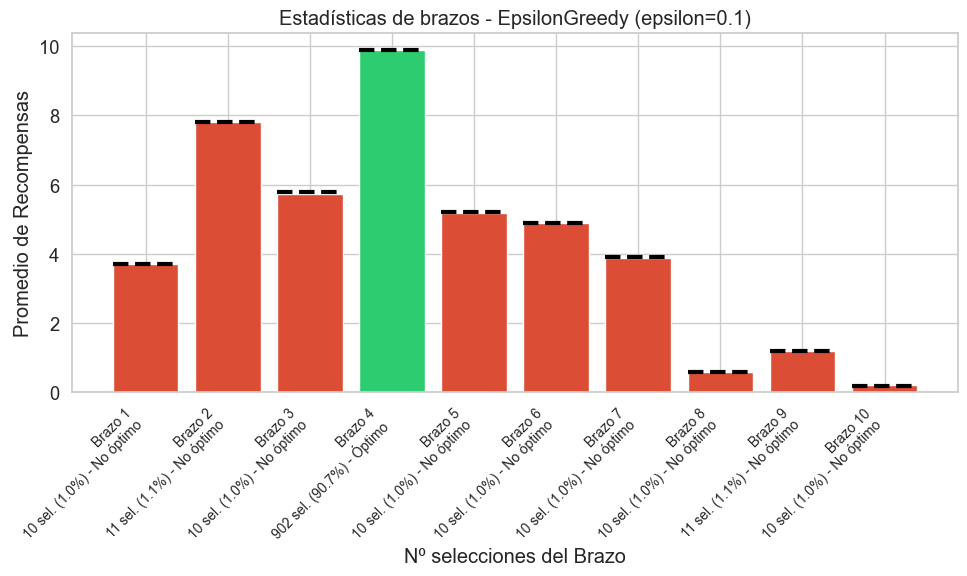

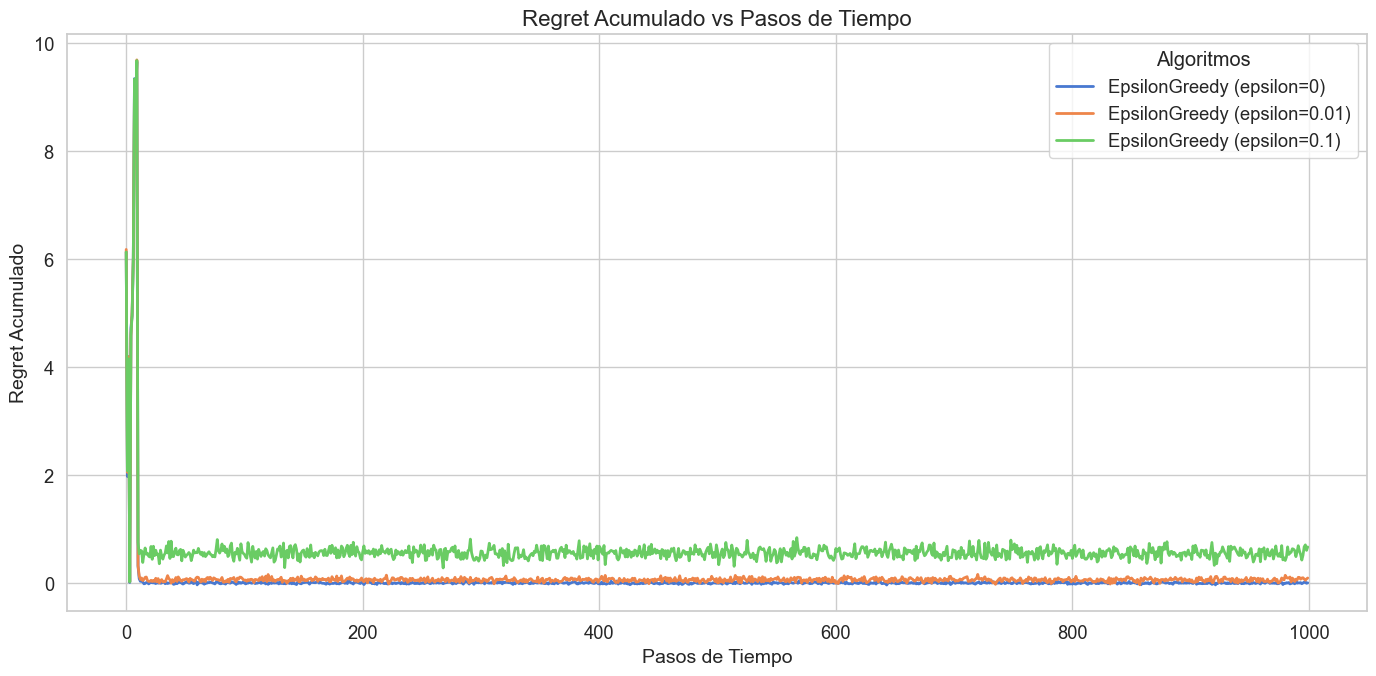

In [ ]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arm_stats, algorithms, [bandit.get_expected_value(i) for i in range(k)])
plot_regret(steps, regrets, algorithms)

### Análisis